# CHORD GNSS visibility capture — how to read the 2026-09-07 data

On 2026-09-07 the six GNSS nodes recorded, for ~5 minutes at full cadence, the
**(N+M)² visibilities** of their L5-band GPU correlator: the **N² block** (all 32 live
antenna elements against each other) *and* the **N×M block** (every element against
the tracker's 32×4 synthetic GNSS replica lanes — a per-element despread). One
visibility every **10.49 ms record** (2048 hops), 6–7 channels per GPU, 12 GPU
instances across 6 nodes, 79 absolute channels in total.

Everything is on the NFS share:

```
/home/kvand/gnss/fixtures/viscap_20260907/
  README.md                  windows, UTC, pointers
  cx19/ cx27/ cx42/ cx43/ cx44/ cx51/
      <node>_gnss<g>_visctl_NNNNNNN.raw    what was correlated (times, PRN table, replica energies)
      <node>_gnss<g>_vistiles_NNNNNNN.raw  the visibilities (int32 16x16 tiles)
  configs/                   the exact node configs that produced the files
  metadata/
      timing.json            sample clock, hop/record/frame geometry, both capture windows in UTC
      channels.csv           (node, gpu) -> the ABSOLUTE freq_ids it correlated
      elements.csv           element_id -> dish, polarisation, grid position
      sat_azel.csv           az/el/range-rate of every GPS/Galileo/BeiDou satellite, 10 s cadence
      station.json           receiver coordinates (+ the array-origin frame the grid is in)
      brdc/                  the broadcast ephemeris used for sat_azel.csv
```

Two things to keep in mind throughout:

* **This is not the production N².** recv1's data set comes from the separate
  `cudaCorrelator` → `n2_accumulate` path, which ran untouched. These files are
  from the GNSS `cudaCorrelatorDual` instance on each GPU.
* **Nothing is per-node.** Axes in this notebook are absolute: `freq_id`
  (MHz = freq_id × 0.1953125), `element_id` (0–127 station id), PRN number.
  Node/GPU only tells you which file holds which channels — see `channels.csv`.

The reader module `viscap_read.py` does the byte-level work; the first half of this
notebook shows what it does by hand so the format is not a black box, the second
half uses it to look at the data. Full format reference: `docs/CHORD_VIS_CAPTURE.md`
and the docstring at the top of `scripts/gnss/viscap_read.py`.

In [1]:
import sys, json, struct, csv
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

sys.path.insert(0, '/home/kvand/gnss/kotekan/scripts/gnss')
import viscap_read as vr

CAP = '/home/kvand/gnss/fixtures/viscap_20260907'
NODE, GPU = 'cx43', 0                       # any of the 12 (node, gpu) instances
D = f'{CAP}/{NODE}'
CFG = f'{CAP}/configs/chord_gnss_{NODE}_multi.yaml'
NODE_YAML = f'{CAP}/configs/chord_gnss_node.yaml'

ctl_files = vr.series(D, NODE, GPU, '', 'visctl')
tile_files = vr.series(D, NODE, GPU, '', 'vistiles')
print(len(ctl_files), 'ctl files +', len(tile_files), 'tiles files for', NODE, 'gpu', GPU)
print(ctl_files[0].split('/')[-1], ' ', tile_files[0].split('/')[-1])

327 ctl files + 327 tiles files for cx43 gpu 0
cx43_gnss0_visctl_0000000.raw   cx43_gnss0_vistiles_0000000.raw


## 1. File framing

Both series are written by kotekan's `rawFileWrite`: each file holds 24 frames, and
each frame on disk is

```
[uint32 metadata_size] [metadata_size bytes of kotekan metadata] [the frame]
```

The kotekan metadata blob can be ignored — everything needed to interpret a frame is
in the **ctl frame** itself. Files are numbered in time order and the ctl and tiles
series are frame-for-frame parallel (ctl frame *k* describes tiles frame *k*).

A ctl frame is

```
FrameHdr   48 B    n_rec, n_prn, n_chan, n_jobs (int32); seq0 (int64); utc0 (float64); ...
winstart   int64[16]                 absolute sample of each record (only n_rec used)
PrnCtl     80 B × 16 × n_prn         the replica table, per record and synth slot
energy     float64 [4·n_prn·16][n_chan]   true (pre-quantisation) replica energy per lane row
```

In [2]:
data = open(ctl_files[0], 'rb').read()
(meta_size,) = struct.unpack_from('<I', data, 0)
hdr = np.frombuffer(data, vr.HDR, 1, 4 + meta_size)[0]
frame_bytes = vr.ctl_frame_bytes(int(hdr['n_prn']), int(hdr['n_chan']))
print('kotekan metadata blob:', meta_size, 'bytes (skip it)')
print('FrameHdr:', {k: hdr[k].item() for k in ('n_rec', 'n_prn', 'n_chan', 'n_jobs', 'seq0', 'utc0')})
print('ctl frame:', frame_bytes, 'bytes ->', len(data) // (4 + meta_size + frame_bytes), 'frames in this file')

kotekan metadata blob: 0 bytes (skip it)
FrameHdr: {'n_rec': 4, 'n_prn': 32, 'n_chan': 7, 'n_jobs': 224, 'seq0': 821989900025856, 'utc0': 1788541059.0000029}
ctl frame: 155824 bytes -> 24 frames in this file


## 2. Time

`seq0` and `winstart` are **absolute F-engine ADC sample counts at 3.2 GS/s**:

| unit | samples | seconds |
|---|---|---|
| hop (one FFT / correlator time sample) | 16 384 | 5.12 µs |
| record (one visibility) | 2048 hops = 33 554 432 | 10.486 ms |
| frame (one file frame, 4 records) | 8192 hops = 134 217 728 | 41.943 ms |

`utc0` is the UTC (Unix seconds) of sample 0, so **UTC of anything = utc0 + seq / 3.2e9**.
`metadata/timing.json` lists the two windows that were captured (a 30 s shakedown, then the
5-minute run) with their seq spans and UTC.

In [3]:
FS, HOP = 3.2e9, 16384
h, win, ctl, energy = vr.decode_ctl(data[4 + meta_size: 4 + meta_size + frame_bytes])
utc = lambda seq: datetime.fromtimestamp(h['utc0'] + seq / FS, tz=timezone.utc)

print('frame 0 starts', utc(h['seq0']).isoformat())
for r in range(h['n_rec']):
    print(f"  record {r}: winstart {win[r]}  {utc(win[r]).strftime('%H:%M:%S.%f')}  (+{(win[r]-h['seq0'])/FS*1e3:.3f} ms, {(win[r]-h['seq0'])//HOP} hops)")

timing = json.load(open(f'{CAP}/metadata/timing.json'))
for w in timing['windows']:
    print(f"window: {w['start_utc'][11:23]} -> {w['end_utc'][11:23]}  {w['n_frames']} frames  seq [{w['start_seq']}, {w['end_seq']})")

frame 0 starts 2026-09-07T16:18:50.843761+00:00
  record 0: winstart 821989900025856  16:18:50.843761  (+0.000 ms, 0 hops)
  record 1: winstart 821989933580288  16:18:50.854247  (+10.486 ms, 2048 hops)
  record 2: winstart 821989967134720  16:18:50.864733  (+20.972 ms, 4096 hops)
  record 3: winstart 821990000689152  16:18:50.875218  (+31.457 ms, 6144 hops)
window: 16:18:50.843 -> 16:19:20.749  713 frames  seq [821989900025856, 822085597265920)
window: 16:20:44.467 -> 16:25:43.521  7130 frames  seq [822353495851008, 823310468251648)


## 3. The PRN table (`PrnCtl`)

The correlator's second input is 128 synthetic lanes = **32 slots × 4 rows**. A slot
carries one satellite's replica (E = early, P = prompt, L = late, P_HEAD = prompt over the
first part of the record). The ctl frame says, **per record and per slot**, whether the
slot ran and which PRN it held:

* `run` — 1 if the slot was live this record (a dead slot's visibilities are exactly 0)
* `prn` — the satellite in the slot **for this record**. Slot↔PRN can change during the
  capture as the tracker swaps satellites, so always index by `prn`, never by slot.
* `fcar_report` — the tracked Doppler (Hz, physical sign); `fcar` — the full replica
  carrier frequency = sky carrier + Doppler (Hz); `f_nco` — the carrier trim applied
  (Hz); `cp_seed` — the code phase at the record reference, chips (a phase *argument*
  in the tracker's export convention — compare them only across records of one PRN)
* `job0` — the row index into the `energy` table for this slot's E row (P is job0+1, ...)

In [4]:
print(' slot  run  PRN   doppler_Hz   fcar_Hz          f_nco_Hz   cp_seed_chips   E_energy(ch3)')
for s, c in enumerate(ctl[0]):
    if c['run']:
        print(f"  {s:3d}  {c['run']:3d}  {c['prn']:3d}  {c['fcar_report']:+10.1f}   {c['fcar']:.1f}   {c['f_nco']:+8.3f}   {c['cp_seed']:12.3f}   {energy[c['job0'], 3]:.3g}")
print('live slots in record 0:', int(ctl[0]['run'].sum()), 'of', h['n_prn'])

 slot  run  PRN   doppler_Hz   fcar_Hz          f_nco_Hz   cp_seed_chips   E_energy(ch3)
    0    1    1     +2607.8   1176452607.8     +0.000      90945.643   1.93e+09
    5    1    6    +68045.1   1176518045.1     +0.000     120014.774   2.12e+09
    7    1    8      -913.5   1176449086.5     +0.000      47849.968   2.19e+09
    8    1    9    +70228.0   1176520228.1     +0.000      71494.729   2.09e+09
    9    1   10      -493.0   1176449507.0     +0.000     187309.252   2.01e+09
   10    1   11    +66450.8   1176516450.8     +0.000     138298.702   1.87e+09
   13    1   14      -308.7   1176449691.3     +0.000      20262.494   1.99e+09
   17    1   18     -2796.2   1176447203.8     +0.000      69392.370   2.03e+09
   20    1   21    +45007.6   1176495007.6     +0.000      66210.960   2.27e+09
   22    1   23     -1767.2   1176448232.8     +0.000     134490.991   2.2e+09
   23    1   24     -1021.2   1176448978.8     +0.000      64953.756   2.19e+09
   26    1   27     -2313.9   11

## 4. The tiles frame

The tiles frame is plain `int32 [n_rec][n_chan][n_tile][16][16][2]` (re, im): the
correlator output is organised as 16×16 tiles of the 256×256 (antennas + synth lanes)
correlation matrix, and only the tiles we need are kept:

* **mixed** (8 × 2 = 16 tiles/channel): synth rows (matrix rows 128–255) × the two
  16-element groups of live antennas. Synth lane *L* = 4·slot + row sits at matrix
  row 128+L; live element *e* (0..31 in live-column order) at matrix column *e*.
  `V_mixed[lane, e] = Σ_hops synth_L · conj(antenna_e)`.
* **AA** (3 tiles/channel): the lower triangle of the 32×32 live-antenna block.
  `V_aa[i, j] = Σ_hops E_i · conj(E_j)`, `i ≥ j`; the reader mirrors the conjugate.

The replicas were quantised to 4 bits before correlation with a per-lane scale
`s = 7 / (3·rms)` (frozen at record 0 of each frame, from the `energy` table). Divide
`vis_mixed` by `scale` to get the tracker's absolute units. `vis_aa` needs no scale.

The frame does not carry the absolute channel ids or the element ids — those come from
the instance's config (`channel_ids` of its `cudaGnssInject`, `live_element_ranges`),
which is why the reader takes the config. `vr.load` does all of the above:

In [5]:
# 10 files = 240 frames = 960 records ~ 10 s, starting just inside the 5-minute window
axes, d = vr.load(D, NODE, GPU, CFG, NODE_YAML, files=slice(30, 40))

print('freq_id  :', axes['freq_id'], ' -> MHz', np.round(axes['freq_id'] * 0.1953125, 3))
print('element_id (live):', axes['element_id'])
print({k: v.shape for k, v in d.items() if v is not None})
t_s = (d['winstart'] - d['winstart'][0]) / FS
print(f"{len(t_s)} records spanning {t_s[-1]:.2f} s from {utc(d['winstart'][0]).isoformat()}")
ich = int(np.argmin(np.abs(axes['freq_id'] * 0.1953125 - 1176.45)))   # the channel on the L5 carrier
print('using channel', ich, '=', axes['freq_id'][ich], f'({axes["freq_id"][ich]*0.1953125:.3f} MHz)')

freq_id  : [5974 5990 6006 6022 6038 6054 6070]  -> MHz [1166.797 1169.922 1173.047 1176.172 1179.297 1182.422 1185.547]
element_id (live): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79]
{'winstart': (960,), 'prn': (960, 32), 'run': (960, 32), 'fcar_report': (960, 32), 'f_nco': (960, 32), 'fcar': (960, 32), 'cp_seed': (960, 32), 'energy': (960, 32, 4, 7), 'scale': (960, 32, 4, 7), 'vis_mixed': (960, 7, 32, 4, 32), 'vis_aa': (960, 7, 32, 32)}
960 records spanning 10.06 s from 2026-09-07T16:20:44.761058+00:00
using channel 3 = 6022 (1176.172 MHz)


## 5. The N² block (`vis_aa`)

32 live elements = 16 dishes × 2 polarisations. Station id convention: **dish = e mod 64,
pol = e div 64**, so elements 0–15 are dishes 0–15 pol 0 and 64–79 the same dishes pol 1
(`metadata/elements.csv` has the dish labels and grid positions).

Below: the correlation coefficient |ρᵢⱼ| = |Vᵢⱼ| / √(Vᵢᵢ Vⱼⱼ) per 10.49 ms record, median
over the 10 s, for two channels of this instance — one at the band edge and one on the
L5 carrier — plus the autocorrelations against time.

max |Im(auto)| over all records/channels = 0.0  (autocorrelations are real by construction)
median off-diagonal |rho| per channel: {5974: 0.019, 5990: 0.106, 6006: 0.202, 6022: 0.239, 6038: 0.221, 6054: 0.108, 6070: 0.02}
noise-only expectation for one 2048-hop record: ~ 0.022
elements with |rho| < 0.08 against EVERY other element on the carrier channel: [4, 5, 7, 12, 68, 69, 71]


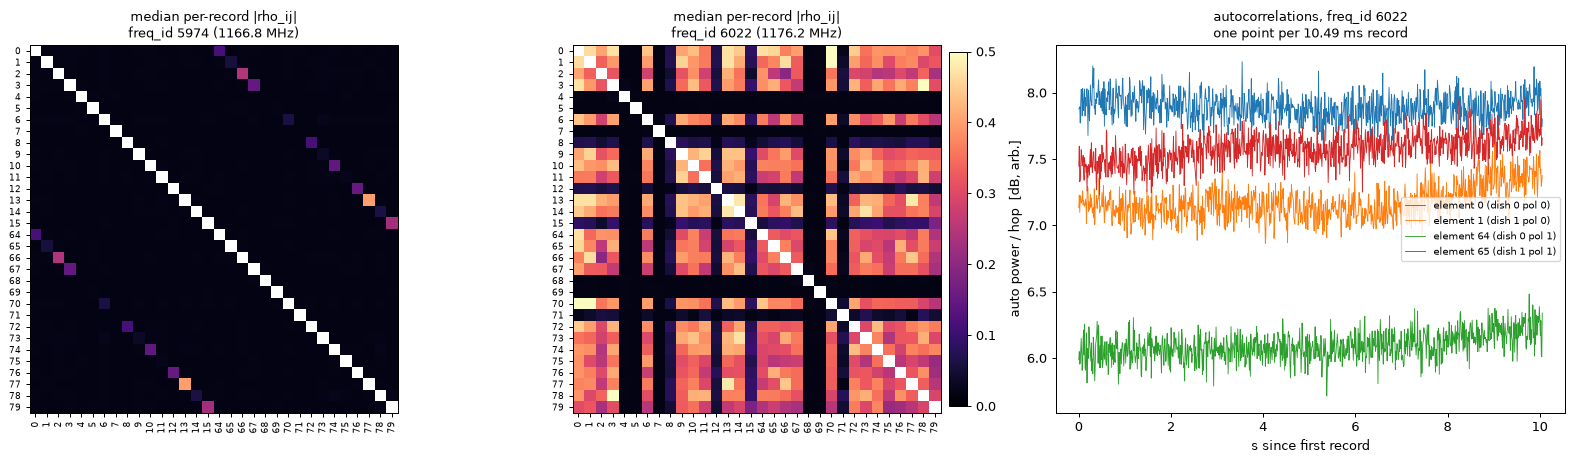

In [6]:
def rho_median(ich):
    aa = d['vis_aa'][:, ich]                                     # [rec][32][32]
    auto = np.real(aa[:, range(32), range(32)])                  # autos are real, positive
    rho = np.median(np.abs(aa) / np.sqrt(auto[:, :, None] * auto[:, None, :]), axis=0)
    np.fill_diagonal(rho, np.nan)
    return rho, auto

print('max |Im(auto)| over all records/channels =',
      np.abs(np.imag(d['vis_aa'][:, :, range(32), range(32)])).max(), ' (autocorrelations are real by construction)')

lab = [str(e) for e in axes['element_id']]
fig, ax = plt.subplots(1, 3, figsize=(18, 5.2), gridspec_kw=dict(width_ratios=(1, 1, 1.15)))
for k, ich_ in enumerate((0, ich)):
    rho, auto = rho_median(ich_)
    im = ax[k].imshow(rho, cmap='magma', vmin=0, vmax=0.5)
    ax[k].set_xticks(range(32)); ax[k].set_yticks(range(32))
    ax[k].set_xticklabels(lab, rotation=90, fontsize=7); ax[k].set_yticklabels(lab, fontsize=7)
    ax[k].set_title(f'median per-record |rho_ij|\nfreq_id {axes["freq_id"][ich_]} ({axes["freq_id"][ich_]*0.1953125:.1f} MHz)', fontsize=10)
plt.colorbar(im, ax=ax[1], fraction=0.04, pad=0.02)
rho, auto = rho_median(ich)
for e in (0, 1, 64, 65):
    k = lab.index(str(e))
    ax[2].plot(t_s, 10*np.log10(auto[:, k] / 2048), lw=.7, label=f'element {e} (dish {e%64} pol {e//64})')
ax[2].set_xlabel('s since first record'); ax[2].set_ylabel('auto power / hop  [dB, arb.]'); ax[2].legend(fontsize=8, loc='center right')
ax[2].set_title(f'autocorrelations, freq_id {axes["freq_id"][ich]}\none point per 10.49 ms record', fontsize=10)
plt.tight_layout()

# the same |rho| statistic across this instance's channels
iu = np.triu_indices(32, 1)
med = [np.nanmedian(rho_median(c)[0][iu]) for c in range(len(axes['freq_id']))]
print('median off-diagonal |rho| per channel:', {int(f): round(float(m), 3) for f, m in zip(axes['freq_id'], med)})
print('noise-only expectation for one 2048-hop record: ~', round(1/np.sqrt(2048), 3))
dark = [int(axes['element_id'][i]) for i in range(32) if np.nanmax(rho[i]) < 0.08]
print('elements with |rho| < 0.08 against EVERY other element on the carrier channel:', dark)

What this shows (observations, not conclusions):

* At the band edges (1166.8 / 1185.5 MHz — the ±10.23 MHz spectral nulls of the L5/E5a/B2a
  BPSK(10) signal) the correlation coefficients sit at the noise-only value ≈ 1/√2048.
  Towards the carrier they rise to ~0.2–0.4 between most element pairs, following the shape
  of the GNSS spectrum: the visibility floor in these channels is the **aggregate GNSS
  signal of every satellite in view**, not noise. Any analysis of one satellite has to
  despread first (next section) or model the others.
* A handful of elements correlate with nothing, on every channel (the black rows/columns).
  Those inputs were not seeing the sky during this capture; drop them or treat them as
  noise references.
* Same-dish cross-polarisation pairs (e.g. 2↔66, 13↔77) correlate even at the band edges:
  common noise inside those dishes.

## 6. The N×M block (`vis_mixed`) — the per-element despread

`vis_mixed[rec, chan, slot, row, e]` is the correlation of element *e* with the replica in
`slot`, row ∈ {0 E, 1 P, 2 L, 3 P_HEAD}. Divided by `scale`, `|V_P|` is the despread
prompt amplitude for that element and that 10.49 ms record — what a single-dish GNSS
receiver's correlator would put out, but for every dish and polarisation at once, with
the phase that lets you beamform.

Two things to know before plotting:

* **Not every live slot is a satellite you can see.** The tracker keeps a few slots on
  *search probes* — replicas swept at tens of kHz of Doppler on PRNs it is not tracking.
  Their output is the noise + common-mode floor, which makes them the ideal null: anything
  a real PRN does that a probe also does is not the satellite. Tell them apart by
  `fcar_report` (|Doppler| > 20 kHz) or by the satellite's elevation in `sat_azel.csv`.
* **E ≈ P ≈ L within one channel is expected.** A 3.125 MHz channel makes the code
  correlation peak ~3 chips wide, so E/P/L (±0.5 chip) sit on one broad bump; the
  tracker sharpens it by combining channels coherently. Per channel, look at |V_P| and
  its phase, not at E−L.

Because slot↔PRN can change, build per-PRN series by masking on `prn` and `run`:

probe (noise-floor) array-mean |V_P|: 101177
|V_P| / probe floor per PRN: {1: 1.7, 8: 1.64, 10: 4.79, 18: 0.92, 23: 1.83, 24: 2.53, 27: 1.66, 28: 0.96, 32: 2.41}


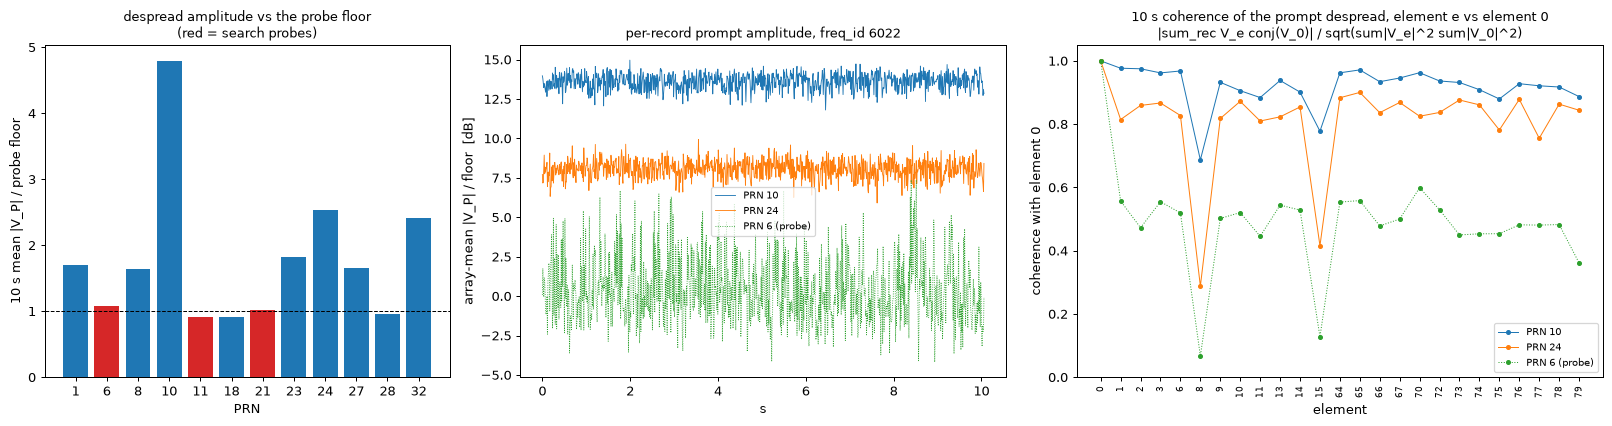

In [7]:
P = 1
scale = d['scale'][:, :, P, ich]
with np.errstate(invalid='ignore'):
    V_all = d['vis_mixed'][:, ich, :, P, :] / np.where(scale > 0, scale, np.nan)[:, :, None]   # [rec][slot][e]
good = np.array([e not in dark for e in axes['element_id']])                               # skip the dark inputs

prns = sorted(set(d['prn'][d['run'] > 0].tolist()))
def prn_series(prn):
    m = (d['prn'] == prn) & (d['run'] > 0)
    rec, slot = np.nonzero(m)
    return rec, V_all[rec, slot][:, good], float(np.median(d['fcar_report'][rec, slot]))

info = {}
for prn in prns:
    rec, V, dop = prn_series(prn)
    amp = np.abs(V).mean(1)                                   # array-mean |V_P| per record
    info[prn] = dict(dop=dop, probe=abs(dop) > 20e3, amp=float(amp.mean()), amp_t=amp, V=V, rec=rec)
noise = np.mean([v['amp'] for v in info.values() if v['probe']])   # the probes ARE the floor

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8), gridspec_kw=dict(width_ratios=(1, 1.2, 1.3)))
cols = ['C3' if info[p]['probe'] else 'C0' for p in prns]
ax[0].bar([str(p) for p in prns], [info[p]['amp'] / noise for p in prns], color=cols)
ax[0].axhline(1, color='k', lw=.8, ls='--'); ax[0].set_xlabel('PRN'); ax[0].set_ylabel('10 s mean |V_P| / probe floor')
ax[0].set_title('despread amplitude vs the probe floor\n(red = search probes)', fontsize=10)
for prn, ls in ((10, '-'), (24, '-'), (6, ':')):
    i = info[prn]
    ax[1].plot(t_s[i['rec']], 20*np.log10(i['amp_t'] / noise), ls, lw=.7, label=f'PRN {prn}' + (' (probe)' if i['probe'] else ''))
ax[1].set_xlabel('s'); ax[1].set_ylabel('array-mean |V_P| / floor  [dB]'); ax[1].legend(fontsize=8)
ax[1].set_title(f'per-record prompt amplitude, freq_id {axes["freq_id"][ich]}', fontsize=10)

# baseline coherence of the despread: does element e see the same satellite as element 0?
ref = 0
for prn, ls in ((10, '-'), (24, '-'), (6, ':')):
    V = info[prn]['V']
    X = (V * np.conj(V[:, [ref]])).sum(0)
    coh = np.abs(X) / np.sqrt((np.abs(V)**2).sum(0) * (np.abs(V[:, ref])**2).sum())
    ax[2].plot(np.arange(good.sum()), coh, 'o' + ls, ms=3, lw=.8, label=f'PRN {prn}' + (' (probe)' if info[prn]['probe'] else ''))
ax[2].set_xticks(range(good.sum())); ax[2].set_xticklabels([str(e) for e in axes['element_id'][good]], rotation=90, fontsize=7)
ax[2].set_ylim(0, 1.05); ax[2].set_xlabel('element'); ax[2].set_ylabel('coherence with element 0')
ax[2].set_title('10 s coherence of the prompt despread, element e vs element 0\n|sum_rec V_e conj(V_0)| / sqrt(sum|V_e|^2 sum|V_0|^2)', fontsize=10)
ax[2].legend(fontsize=8, loc='lower right')
plt.tight_layout()
print('probe (noise-floor) array-mean |V_P|: %.0f' % noise)
print('|V_P| / probe floor per PRN:', {p: round(float(v['amp'] / noise), 2) for p, v in info.items() if not v['probe']})

The despread of PRN 10 (71° elevation) is coherent across the array at the 0.9+ level — a
stable phase per element over the 10 s, which is the calibration signal this data set was
asked for. The probe slot (PRN 6, below the horizon) is *not* at zero: the common-mode
GNSS ensemble seen in the N² block leaks through any replica, so the probes define the
floor that a "detection" has to beat, and their element phase pattern is the pattern of
that ensemble, not of a satellite.

## 7. Joining the metadata: dishes, satellites, geometry

`elements.csv` maps `element_id` → dish/pol/grid position; `sat_azel.csv` gives az/el/range
rate for every satellite at 10 s cadence (computed with the broker's own ephemeris code at
the receiver coordinates in `station.json`); `channels.csv` says which (node, gpu) file
holds which absolute channel.

In [8]:
elements = {int(r['element_id']): r for r in csv.DictReader(open(f'{CAP}/metadata/elements.csv'))}
print('element 0 :', dict(elements[0]))
print('element 64:', dict(elements[64]))

t0 = h['utc0'] + d['winstart'][0] / FS
rows = [r for r in csv.DictReader(open(f'{CAP}/metadata/sat_azel.csv')) if r['sys'] == 'G']
ts = np.array(sorted(set(float(r['utc_unix']) for r in rows)))
tn = ts[np.argmin(np.abs(ts - t0))]
azel = {int(r['prn']): (float(r['az_deg']), float(r['el_deg']), float(r['range_rate_mps'])) for r in rows if float(r['utc_unix']) == tn}
C, F_L5 = 299792458.0, 1176.45e6

print(f'\nGPS sky at {datetime.fromtimestamp(tn, tz=timezone.utc).isoformat()} (closest 10 s epoch to our slice):')
print(' PRN     az     el   Doppler predicted   Doppler tracked   |V_P|/floor')
for prn in prns:
    az, el, rr = azel[prn]
    i = info[prn]
    tag = '  <- search probe' if i['probe'] else ''
    print(f"  {prn:3d}  {az:6.1f}  {el:5.1f}   {-rr/C*F_L5:+9.1f} Hz      {i['dop']:+9.1f} Hz     {i['amp']/noise:5.2f}{tag}")

print('\nall GPS above 5 deg:', sorted((p, round(v[1], 1)) for p, v in azel.items() if v[1] > 5))
print('(L5 is broadcast by Block IIF and later; PRN 2 is a Block IIR-M satellite with no L5 signal)')

element 0 : {'element_id': '0', 'dish_idx': '0', 'pol': '0', 'label': 'B4', 'grid_x_idx': '3', 'grid_y_idx': '1', 'grid_x_m': '18.9005', 'grid_y_m': '8.5001'}
element 64: {'element_id': '64', 'dish_idx': '0', 'pol': '1', 'label': 'B4', 'grid_x_idx': '3', 'grid_y_idx': '1', 'grid_x_m': '18.9005', 'grid_y_m': '8.5001'}

GPS sky at 2026-09-07T16:20:44.467000+00:00 (closest 10 s epoch to our slice):
 PRN     az     el   Doppler predicted   Doppler tracked   |V_P|/floor
    1   307.2   11.9     +2602.9 Hz        +2601.1 Hz      1.70
    6   325.8  -70.7      +948.7 Hz       +68179.9 Hz      1.08  <- search probe
    8   267.5   34.1      -962.4 Hz         -965.4 Hz      1.64
   10    53.4   71.6      -520.3 Hz         -522.3 Hz      4.79
   11    90.7  -82.0      -262.8 Hz       +66904.4 Hz      0.91  <- search probe
   18   134.7    4.3     -2802.5 Hz        -2803.5 Hz      0.92
   21    96.5  -67.5      -895.6 Hz       +45054.9 Hz      1.01  <- search probe
   23    78.4   38.8     -1785.

The tracked Doppler follows the ephemeris prediction to within a few Hz for every real
satellite (the difference is the receiver clock's rate); the probes are the rows whose
"tracked" Doppler is tens of kHz off. Amplitude against the probe floor tracks elevation,
as it should for dishes that are not pointed at any of them.

## 8. Shortcuts, caveats, further reading

* **One-shot HDF5**: `viscap_read.py <dir>/<node> --node <node> --gpu <g> --config
  <dir>/configs/chord_gnss_<node>_multi.yaml --node-yaml <dir>/configs/chord_gnss_node.yaml
  --to-h5 out.h5` writes every array used above (`vis_aa`, `vis_mixed`, `scale`, `prn`, `run`,
  `fcar_report`, `winstart`, `freq_id`, `element_id`, ...) for the whole series. A whole
  instance is ~18 GB in; try `--max-frames 240` first.
* **Combining instances**: concatenate along `freq_id`; align in time on `winstart`
  (identical across nodes — one F-engine clock). Never treat a node or GPU as an axis.
* **Dead slots are exactly zero**; probe slots are not (see §6). The `energy` table is the
  true replica energy; the quantised replica's differs by the 4-bit rounding that `scale`
  accounts for.
* **Coordinates**: `station.json` has two points on purpose — the receiver point the az/el
  are computed at, and the array origin that `elements.csv` grid offsets are measured from
  (~155 m apart). Don't mix them.
* The PRNs present are the ones the tracker had seeded when the capture ran, not
  everything above the horizon.
* Format reference and the capture mechanism: `kotekan/docs/CHORD_VIS_CAPTURE.md`; the
  byte-level contract lives in the docstring of `kotekan/scripts/gnss/viscap_read.py`.
  Re-execute this notebook without Jupyter with `scripts/gnss/nb_run.py viscap_tutorial.ipynb`.